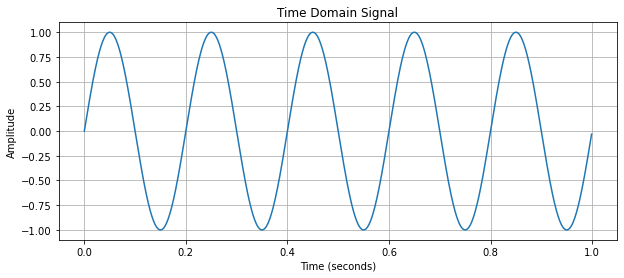

In [1]:
import numpy as np
import matplotlib.pyplot as plt

def plot_time(x, fs):
    """
    Plots a signal in the time domain.
    
    Parameters:
    x (numpy array): The signal to plot.
    fs (float): The sampling frequency in Hz.
    """
    # Create a time array from 0 to the length of x, spaced by the sampling interval.
    t = np.linspace(0, len(x) / fs, num=len(x), endpoint=False)
    
    # Create the plot.
    plt.figure(figsize=(10, 4))
    plt.plot(t, x)
    plt.title("Time Domain Signal")
    plt.xlabel("Time (seconds)")
    plt.ylabel("Amplitude")
    plt.grid(True)
    plt.show()

# Example usage:
# Generate a sample signal (e.g., a sine wave)
fs = 1000  # Sampling frequency in Hz
t = np.linspace(0, 1, fs, endpoint=False)  # 1 second time vector
x = np.sin(2 * np.pi * 5 * t)  # 5 Hz sine wave

# Call the function to plot the signal
plot_time(x, fs)


## Question 1b

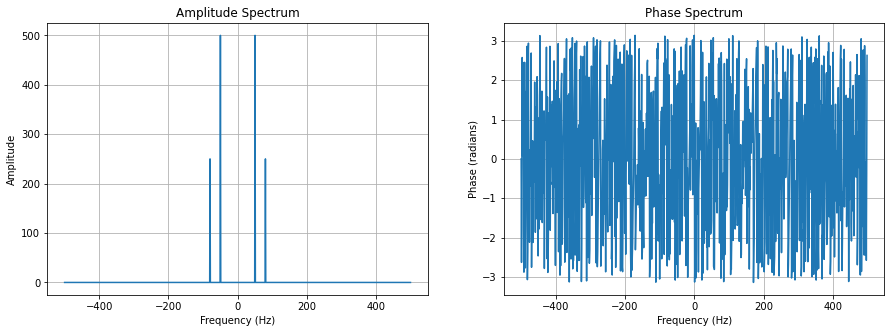

In [3]:
import numpy as np
import matplotlib.pyplot as plt

def plot_freq(X, fs):
    """
    Plots a signal in the frequency domain.
    
    Parameters:
    X (numpy array): The complex-valued frequency domain representation of the signal.
    fs (float): The sampling frequency in Hz.
    """
    # Compute the number of points in the signal
    n = len(X)
    
    # Create the frequency array for plotting
    freq = np.fft.fftshift(np.fft.fftfreq(n, d=1/fs))
    
    # Compute the shifted amplitude and phase spectra
    X_shifted = np.fft.fftshift(X)
    amplitude = np.abs(X_shifted)
    phase = np.angle(X_shifted)
    
    # Create the plots
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))
    
    # Plot amplitude spectrum
    ax1.plot(freq, amplitude)
    ax1.set_title("Amplitude Spectrum")
    ax1.set_xlabel("Frequency (Hz)")
    ax1.set_ylabel("Amplitude")
    ax1.grid(True)
    
    # Plot phase spectrum
    ax2.plot(freq, phase)
    ax2.set_title("Phase Spectrum")
    ax2.set_xlabel("Frequency (Hz)")
    ax2.set_ylabel("Phase (radians)")
    ax2.grid(True)
    
    # Display the plots
    plt.show()

# Example usage:
# Generate a sample signal
fs = 1000  # Sampling frequency in Hz
t = np.linspace(0, 1, fs, endpoint=False)  # 1 second time vector
x = np.sin(2 * np.pi * 50 * t) + 0.5 * np.sin(2 * np.pi * 80 * t)  # Composite signal

# Compute its Fourier Transform
X = np.fft.fft(x)

# Call the function to plot the frequency domain representation
plot_freq(X, fs)


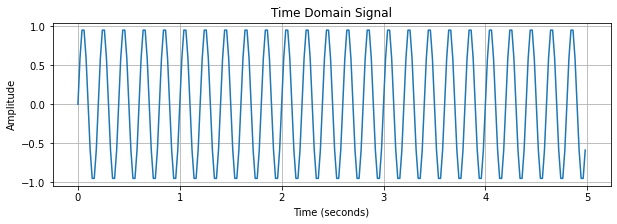

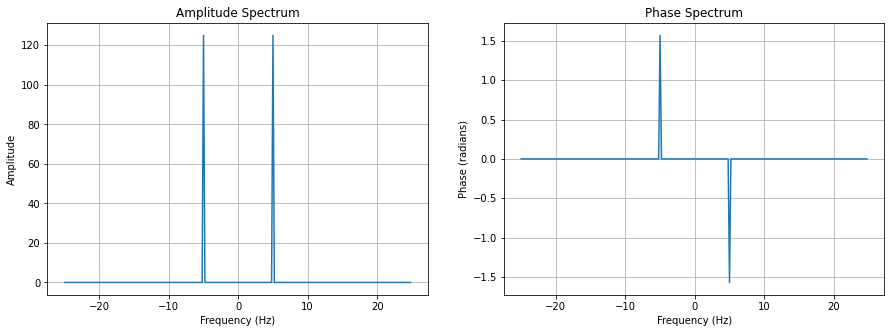

In [6]:
import numpy as np
import matplotlib.pyplot as plt

def plot_time(x, fs):
    t = np.linspace(0, len(x) / fs, num=len(x), endpoint=False)
    plt.figure(figsize=(10, 3))
    plt.plot(t, x)
    plt.title("Time Domain Signal")
    plt.xlabel("Time (seconds)")
    plt.ylabel("Amplitude")
    plt.grid(True)
    plt.show()

def plot_freq(X, fs,threshold=1e-5):
    n = len(X)
    freq = np.fft.fftshift(np.fft.fftfreq(n, d=1/fs))
    X_shifted = np.fft.fftshift(X)
    amplitude = np.abs(X_shifted)
    phase = np.angle(X_shifted)
    
    phase[amplitude < threshold] = 0
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))
    ax1.plot(freq, amplitude)
    ax1.set_title("Amplitude Spectrum")
    ax1.set_xlabel("Frequency (Hz)")
    ax1.set_ylabel("Amplitude")
    ax1.grid(True)
    
    ax2.plot(freq, phase)
    ax2.set_title("Phase Spectrum")
    ax2.set_xlabel("Frequency (Hz)")
    ax2.set_ylabel("Phase (radians)")
    ax2.grid(True)
    plt.show()

# Parameters
fs = 50  # Sampling frequency
T = 5    # Duration in seconds
f = 5    # Frequency of the sine wave

# Generate the signal
t = np.linspace(0, T, int(T * fs), endpoint=False)  # Time vector
x = np.sin(2 * np.pi * f * t)  # Sine wave

# Compute its DFT
X = np.fft.fft(x)

# Plot the signal and its frequency spectrum
plot_time(x, fs)
plot_freq(X, fs)


## Question2

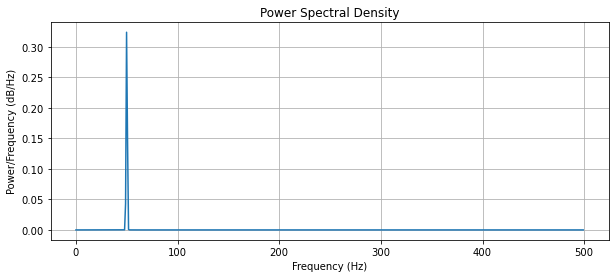

In [8]:
import numpy as np
import matplotlib.pyplot as plt

def psd(x, w, fs):
    # Apply the window to the signal
    xw = x * w
    
    # Compute the Fourier Transform
    X = np.fft.fft(xw)
    
    # Compute the power spectrum
    S = np.sum(w**2)
    psd = 2 * (np.abs(X) ** 2) / (fs * S)
    
    # Only consider the positive frequencies
    half = len(x) // 2
    freq = np.fft.fftfreq(len(x), d=1/fs)[:half]
    psd = psd[:half]
    
    return freq, psd

# Example of a window function and signal generation
N = 1024  # Number of samples
fs = 1000  # Sampling frequency in Hz
t = np.linspace(0, N/fs, N, endpoint=False)
x = np.sin(2 * np.pi * 50 * t)  # A 50 Hz sine wave
w = np.hanning(N)  # Using a Hanning window

freq, psd_values = psd(x, w, fs)

# Plot the PSD
plt.figure(figsize=(10, 4))
plt.plot(freq, psd_values)
plt.title('Power Spectral Density')
plt.xlabel('Frequency (Hz)')
plt.ylabel('Power/Frequency (dB/Hz)')
plt.grid(True)
plt.show()


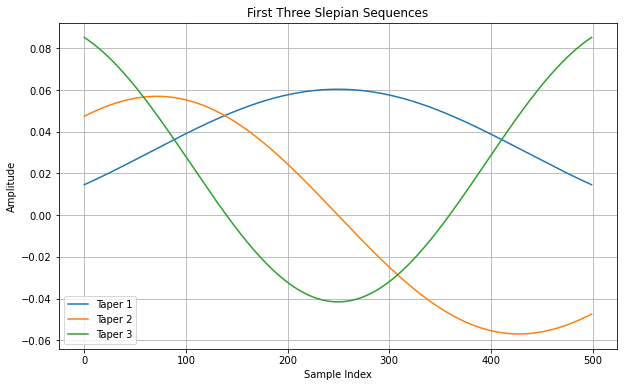

In [10]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal.windows import dpss

# Parameters
M = 500  # Length of each taper
NW = 1   # Time-bandwidth product
K = 3    # Number of tapers

# Generate the first three Slepian sequences
tapers = dpss(M, NW, K)

# Plot all three tapers
plt.figure(figsize=(10, 6))
for i, taper in enumerate(tapers):
    plt.plot(taper, label=f'Taper {i+1}')
plt.title('First Three Slepian Sequences')
plt.xlabel('Sample Index')
plt.ylabel('Amplitude')
plt.legend()
plt.grid(True)
plt.show()


## Verifying Orthogonality of Tapers

- For two vectors to be orthogonal, their dot product must be zero or close to zero within a computational tolerance due to floating-point arithmetic

In [13]:
# Compute and print the dot products to verify orthogonality
print("Dot Products Between Tapers:")
for i in range(K):
    for j in range(i + 1, K):
        dot_product = np.dot(tapers[i], tapers[j])
        print(f"Dot product between Taper {i+1} and Taper {j+1}: {dot_product:.2e}")


Dot Products Between Tapers:
Dot product between Taper 1 and Taper 2: -7.70e-18
Dot product between Taper 1 and Taper 3: -9.76e-19
Dot product between Taper 2 and Taper 3: -2.08e-17


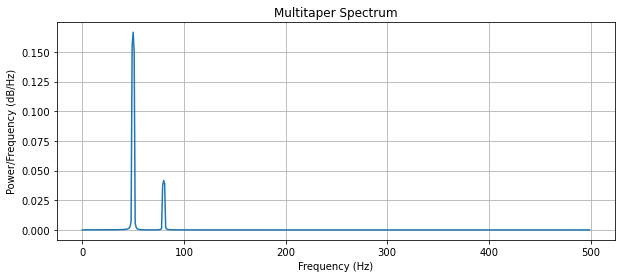

In [12]:
import numpy as np
from scipy.signal.windows import dpss


def multitaper(x, fs, k):
    N = len(x)  # Length of the signal
    duration = N / fs  # Duration of the signal in seconds
    NW = duration  # Set NW to the signal's duration in seconds
    tapers = dpss(N, NW, k)  # Generate tapers
    
    psds = []  # List to hold all PSDs
    for w in tapers:
        _, psd_values = psd(x, w, fs)  # Compute the PSD for each taper
        psds.append(psd_values)
    
    psds = np.array(psds)  # Convert list of PSDs to a NumPy array
    avg_psd = np.mean(psds, axis=0)  # Average the PSDs across the tapers
    
    freq = np.fft.fftfreq(N, d=1/fs)[:N//2]  # Frequency axis
    return freq, avg_psd

# Example usage
fs = 1000  # Example sampling frequency
t = np.linspace(0, 1, fs, endpoint=False)  # Time vector for one second
x = np.sin(2 * np.pi * 50 * t) + 0.5 * np.sin(2 * np.pi * 80 * t)  # Example signal
k = 3  # Number of tapers

freq, avg_psd = multitaper(x, fs, k)

# Plotting the multitaper spectrum
plt.figure(figsize=(10, 4))
plt.plot(freq, avg_psd)
plt.title('Multitaper Spectrum')
plt.xlabel('Frequency (Hz)')
plt.ylabel('Power/Frequency (dB/Hz)')
plt.grid(True)
plt.show()


Sampling frequency: 22050


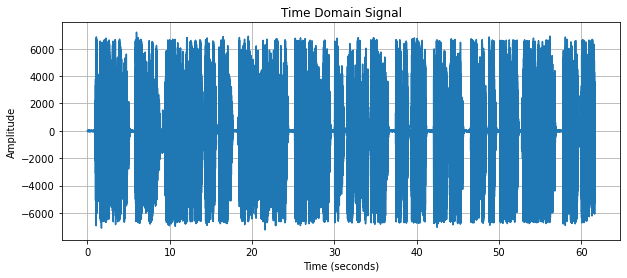

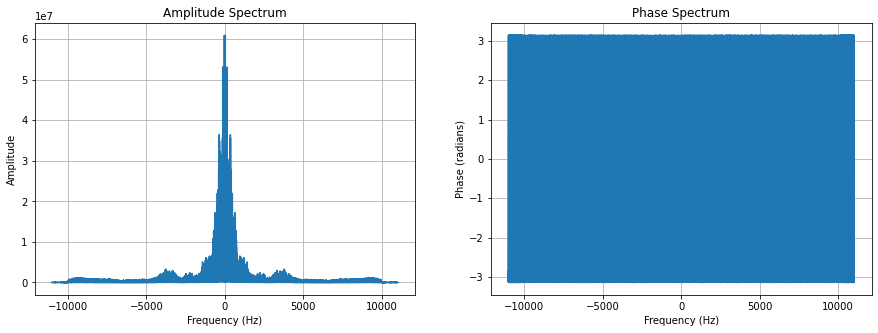

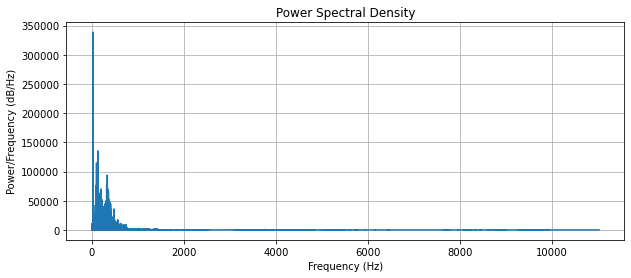

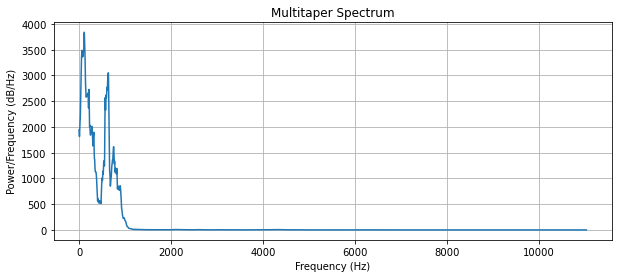

In [18]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.io import wavfile
from scipy.signal.windows import dpss

# Assume the previously defined psd and multitaper functions are imported

def plot_time(x, fs):
    t = np.linspace(0, len(x) / fs, num=len(x), endpoint=False)
    plt.figure(figsize=(10, 4))
    plt.plot(t, x)
    plt.title("Time Domain Signal")
    plt.xlabel("Time (seconds)")
    plt.ylabel("Amplitude")
    plt.grid(True)
    plt.show()

def plot_freq(X, fs):
    n = len(X)
    freq = np.fft.fftshift(np.fft.fftfreq(n, d=1/fs))
    X_shifted = np.fft.fftshift(X)
    amplitude = np.abs(X_shifted)
    phase = np.angle(X_shifted)
    
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))
    ax1.plot(freq, amplitude)
    ax1.set_title("Amplitude Spectrum")
    ax1.set_xlabel("Frequency (Hz)")
    ax1.set_ylabel("Amplitude")
    ax1.grid(True)
    
    ax2.plot(freq, phase)
    ax2.set_title("Phase Spectrum")
    ax2.set_xlabel("Frequency (Hz)")
    ax2.set_ylabel("Phase (radians)")
    ax2.grid(True)
    plt.show()

# Step 1: Load the audio file
fs, x = wavfile.read('speech.wav')  # Adjust path if necessary

# Step 2: Print the sampling frequency
print("Sampling frequency:", fs)

# Step 3: Plot the signal in the time domain
plot_time(x, fs)

# Step 4: Compute and plot the frequency domain representation
X = np.fft.fft(x)
plot_freq(X, fs)

# Step 5: Compute and plot the PSD using a Hanning window
w = np.hanning(len(x))
_, psd_values = psd(x, w, fs)
plt.figure(figsize=(10, 4))
plt.plot(np.fft.fftfreq(len(x), d=1/fs)[:len(x)//2], psd_values)
plt.title('Power Spectral Density')
plt.xlabel('Frequency (Hz)')
plt.ylabel('Power/Frequency (dB/Hz)')
plt.grid(True)
plt.show()

# Step 6: Compute and plot the multitaper spectrum using 20 tapers
_, multitaper_psd = multitaper(x, fs, 20)
plt.figure(figsize=(10, 4))
plt.plot(np.fft.fftfreq(len(x), d=1/fs)[:len(x)//2], multitaper_psd)
plt.title('Multitaper Spectrum')
plt.xlabel('Frequency (Hz)')
plt.ylabel('Power/Frequency (dB/Hz)')
plt.grid(True)
plt.show()

# Observation: Provide comments based on the above plots and analyses.


## Question 3


- Not Right

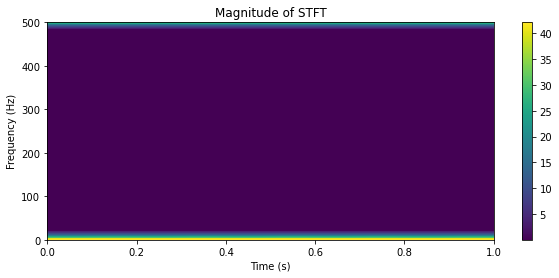

In [21]:
import numpy as np
from scipy.signal.windows import hann
from numpy.fft import fft

def stft(x, fs, wlen, win_func=True):
    # Number of samples per window
    sample_per_window = int(wlen * fs)
    # Number of possible windows based on the signal length and window size
    n_windows = len(x) // sample_per_window
    # Pre-allocate the STFT output array
    stft_output = np.zeros((n_windows, sample_per_window // 2 + 1), dtype=complex)
    
    # Window function
    window = np.hanning(sample_per_window) if win_func else np.ones(sample_per_window)
    
    # Compute the STFT
    for i in range(n_windows):
        start_idx = i * sample_per_window
        end_idx = start_idx + sample_per_window
        segment = x[start_idx:end_idx]
        # Apply the window and compute FFT
        segment_fft = np.fft.rfft(segment * window)
        stft_output[i, :] = segment_fft
    
    return stft_output


# Example usage:
fs = 1000  # Example sampling frequency in Hz
wlen = 0.1  # Window length of 0.1 seconds
t = np.linspace(0, 1, fs, endpoint=False)  # Generate 1 second of data
x = np.sin(2 * np.pi * 5 * t) + 0.5 * np.sin(2 * np.pi * 20 * t)  # Mixed frequency signal

# Call the STFT function
result = stft(x, fs, wlen, win_func=True)

# For plotting the magnitude of the STFT result
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 4))
plt.imshow(np.abs(result.T), aspect='auto', origin='lower',
           extent=[0, 1, 0, fs/2])
plt.colorbar()
plt.title('Magnitude of STFT')
plt.ylabel('Frequency (Hz)')
plt.xlabel('Time (s)')
plt.show()


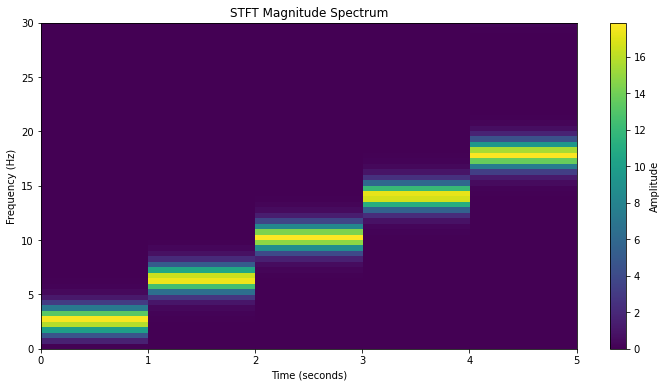

In [25]:
import numpy as np
import matplotlib.pyplot as plt

fs = 100  # Sampling frequency
t = np.linspace(0, 5, 5 * fs, endpoint=False)  # Time vector for 5 seconds
# Creating a chirp signal from 1 Hz to 20 Hz over 5 seconds
x = np.sin(2 * np.pi * (1 + (t * (20 - 1) / 5)) * t)



x_stft = stft(x, fs, 1, win_func=True)
def plot_stft(x_stft, fs, fmax=30):
    # Time and frequency axes setup
    n_windows, n_frequencies = x_stft.shape
    time_axis = np.linspace(0, n_windows * (len(x) / fs) / n_windows, n_windows)
    freq_axis = np.linspace(0, fs / 2, n_frequencies)
    
    plt.figure(figsize=(12, 6))
    plt.imshow(np.abs(x_stft.T), aspect='auto', origin='lower',
               extent=[time_axis[0], time_axis[-1], freq_axis[0], freq_axis[-1]],
               vmin=0, vmax=None, cmap='viridis')
    plt.colorbar(label='Amplitude')
    plt.title('STFT Magnitude Spectrum')
    plt.xlabel('Time (seconds)')
    plt.ylabel('Frequency (Hz)')
    plt.ylim([0, fmax])  # Limiting frequency display to 'fmax'
    plt.show()


plot_stft(x_stft, fs, fmax=30)


## Question 4

In [26]:
pip install scipy sounddevice


Note: you may need to restart the kernel to use updated packages.


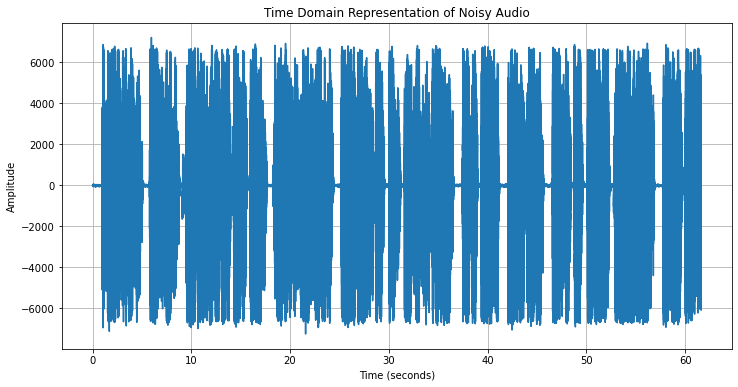

In [29]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.io import wavfile
import sounddevice as sd

# Load the audio file
fs, x = wavfile.read('speech.wav')  # Make sure to provide the correct path to the file

# Play the audio file
sd.play(x, fs)
sd.wait()  # Wait until the file is played completely

# Plot the audio signal in the time domain
t = np.linspace(0, len(x) / fs, num=len(x), endpoint=False)  # Time vector in seconds

plt.figure(figsize=(12, 6))
plt.plot(t, x)
plt.title('Time Domain Representation of Noisy Audio')
plt.xlabel('Time (seconds)')
plt.ylabel('Amplitude')
plt.grid(True)
plt.show()


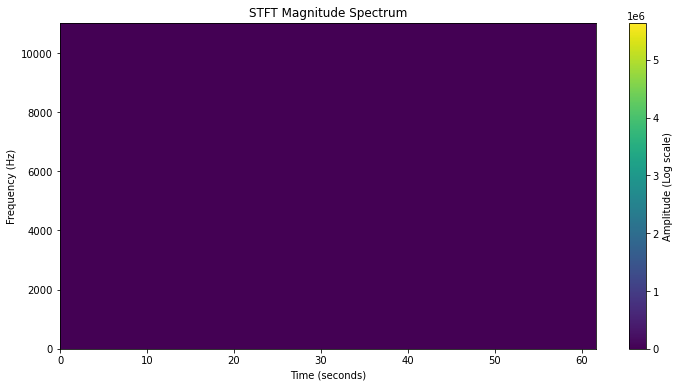

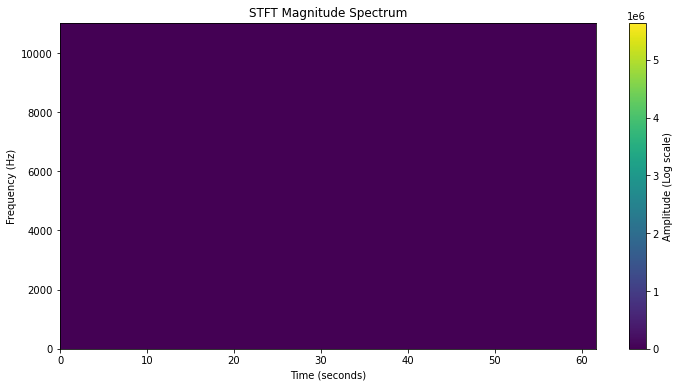

Frequency resolution: 5.0 Hz


In [30]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.io import wavfile
from scipy.signal.windows import hann

def stft(x, fs, wlen, win_func=False):
    sample_per_window = int(wlen * fs)
    n_windows = len(x) // sample_per_window
    stft_output = np.zeros((n_windows, sample_per_window // 2 + 1), dtype=complex)
    window = hann(sample_per_window) if win_func else np.ones(sample_per_window)
    
    for i in range(n_windows):
        start_idx = i * sample_per_window
        end_idx = start_idx + sample_per_window
        segment = x[start_idx:end_idx]
        segment = segment * window  # Apply the window function
        stft_output[i, :] = np.fft.rfft(segment)
    
    return stft_output

def plot_stft(x_stft, fs, wlen, fmax=None, log=False, colormap_min=None, colormap_max=None):
    time_step = wlen
    freq_step = fs / (len(x_stft[0]) * 2)
    extent = [0, len(x_stft) * time_step, 0, fs / 2]
    
    plt.figure(figsize=(12, 6))
    if log:
        plt.imshow(np.log(np.abs(x_stft.T) + 1), aspect='auto', origin='lower',
                   extent=extent, vmin=colormap_min, vmax=colormap_max, cmap='viridis')
    else:
        plt.imshow(np.abs(x_stft.T), aspect='auto', origin='lower',
                   extent=extent, vmin=colormap_min, vmax=colormap_max, cmap='viridis')
    plt.colorbar(label='Amplitude (Log scale)')
    plt.title('STFT Magnitude Spectrum')
    plt.ylabel('Frequency (Hz)')
    plt.xlabel('Time (seconds)')
    plt.show()

# Load audio data
fs, x = wavfile.read('speech.wav')

# Compute the STFT with and without the Hann window
wlen = 0.2
stft_no_window = stft(x, fs, wlen, win_func=False)
stft_hann_window = stft(x, fs, wlen, win_func=True)

# Find max amplitude for consistent color scaling
max_amplitude = max(np.max(np.abs(stft_no_window)), np.max(np.abs(stft_hann_window)))

# Plotting
plot_stft(stft_no_window, fs, wlen, log=True, colormap_min=0, colormap_max=max_amplitude)
plot_stft(stft_hann_window, fs, wlen, log=True, colormap_min=0, colormap_max=max_amplitude)

# Frequency resolution
freq_res = fs / (int(wlen * fs))
print(f"Frequency resolution: {freq_res} Hz")


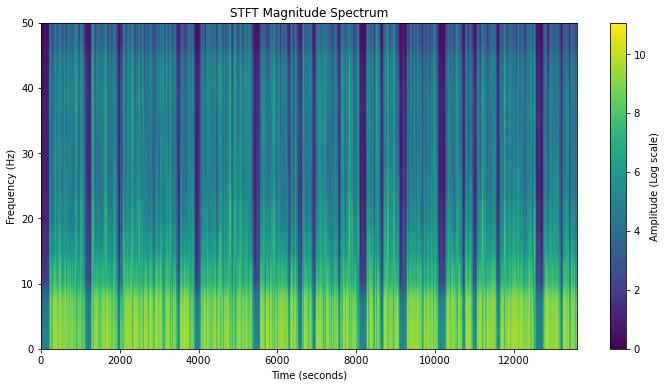

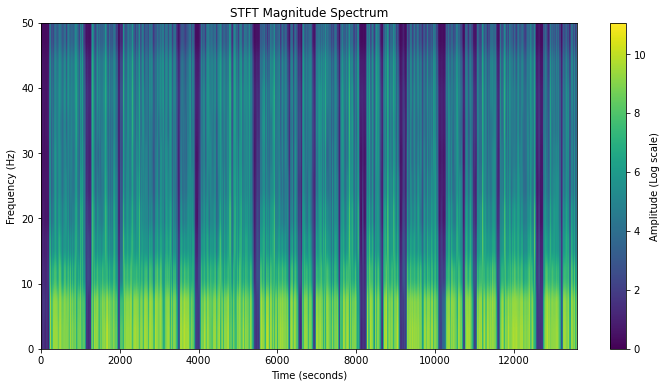

In [31]:
import numpy as np

def noise_gate(W, t_noise, c_thresh, fs):
    # Calculate the number of samples in the noise epoch
    samples_in_noise = int(t_noise * fs)
    
    # Since each segment is 0.2 seconds (given wlen=0.2 from earlier parts), calculate how many segments this includes
    segments_in_noise = int(samples_in_noise / (0.2 * fs))
    
    # Extract the noise-only segments from W
    W_noise = W[:segments_in_noise, :]
    
    # Compute the mean (µ) and standard deviation (σ) of the log-scaled amplitudes in the noise segments
    log_amplitudes = np.log(np.abs(W_noise) + 1)  # Adding 1 to avoid log(0)
    mu = np.mean(log_amplitudes, axis=0)
    sigma = np.std(log_amplitudes, axis=0)
    
    # Calculate the noise gate threshold
    threshold = mu + (c_thresh * sigma)
    
    # Apply the noise gate to the entire matrix W
    W_clean = np.copy(W)
    for i in range(W.shape[0]):
        for j in range(W.shape[1]):
            if np.log(np.abs(W[i, j]) + 1) < threshold[j]:
                W_clean[i, j] = 0  # Setting the amplitude to zero if below threshold

    return W_clean

# Example Usage
fs = 100  # Example sampling frequency in Hz
W = stft(x, fs, 0.2, win_func=True)  # Assuming 'x' is loaded and 'stft' is already defined
W_clean = noise_gate(W, t_noise=5, c_thresh=1.5, fs=fs)  # Example threshold factor

# Plot the original and cleaned STFT
plot_stft(W, fs, 0.2, log=True, colormap_min=None, colormap_max=None)
plot_stft(W_clean, fs, 0.2, log=True, colormap_min=None, colormap_max=None)


In [32]:
import numpy as np

def istft(X_stft, fs, wlen, win_func=False):
    n_windows, n_frequencies = X_stft.shape
    sample_per_window = int(wlen * fs)
    # Initialize the time-domain signal
    x_reconstructed = np.zeros(n_windows * sample_per_window)
    window = np.hanning(sample_per_window) if win_func else np.ones(sample_per_window)
    
    for i in range(n_windows):
        start_idx = i * sample_per_window
        # Compute the inverse FFT
        ifft_segment = np.fft.irfft(X_stft[i, :])
        # Apply the window and add to the output signal
        x_reconstructed[start_idx:start_idx + sample_per_window] += ifft_segment * window
    
    return x_reconstructed

# Parameters
fs = 100  # Example sampling frequency in Hz, adjust as needed
wlen = 0.2  # Window length of 0.2 seconds


In [33]:
# Compute the inverse STFT for both windowed and non-windowed cleaned signals
z_clean_no_window = istft(W_clean, fs, wlen, win_func=False)
z_clean_hann_window = istft(W_clean, fs, wlen, win_func=True)

# Scaling the signals to 16-bit integer range
z_clean_no_window_scaled = np.int16(z_clean_no_window / np.max(np.abs(z_clean_no_window)) * 32767)
z_clean_hann_window_scaled = np.int16(z_clean_hann_window / np.max(np.abs(z_clean_hann_window)) * 32767)

# Saving the cleaned audio signals
from scipy.io.wavfile import write

write('cleaned_no_window.wav', fs, z_clean_no_window_scaled)
write('cleaned_hann_window.wav', fs, z_clean_hann_window_scaled)


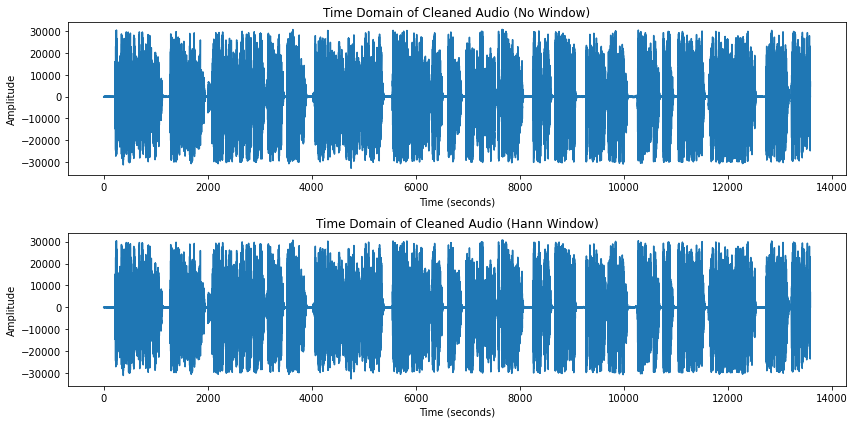

In [34]:
import matplotlib.pyplot as plt

# Time vectors for plotting
t = np.linspace(0, len(z_clean_no_window) / fs, num=len(z_clean_no_window))

plt.figure(figsize=(12, 6))
plt.subplot(2, 1, 1)
plt.plot(t, z_clean_no_window_scaled)
plt.title('Time Domain of Cleaned Audio (No Window)')
plt.xlabel('Time (seconds)')
plt.ylabel('Amplitude')

plt.subplot(2, 1, 2)
plt.plot(t, z_clean_hann_window_scaled)
plt.title('Time Domain of Cleaned Audio (Hann Window)')
plt.xlabel('Time (seconds)')
plt.ylabel('Amplitude')

plt.tight_layout()
plt.show()
